# Práctica PySpark ML
Dado el siguente dataset:

https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

Cuyas variables representan:

- `age`: edad del beneficiario principal
- `sex`: género del contratante del seguro, femenino, masculino
- `bmi`: índice de masa corporal, que proporciona una comprensión del cuerpo, de los pesos que son relativamente altos o bajos en relación con la altura, índice objetivo de peso corporal (kg / m ^ 2) utilizando la relación entre la altura y el peso, idealmente entre 18,5 y 24,9.
- `children`: número de hijos cubiertos por el seguro de salud / número de dependientes
- `smoker`: si fuma o no
- `region`: área de residencia del beneficiario en EE. UU., noreste, sureste, suroeste, noroeste.
- `charges`: costos médicos individuales facturados por el seguro de salud.


**Primera parte**: Realizar un EDA del dataset anterior utilizando la API de pandas de PySpark (import pyspark.pandas as ps)

**Segunda parte**: Convertirlos a un DataFrame de Spark normal, realizar las conversiones necesarias para poder hacer machine learning (StringIndexer, StandardScaler, VectorAssembler...) y aplica un modelo de regresión lineal usando pyspark.ml (la variable objetivo a predecir es `charges`).

*Nota: Este proyecto se ha realizado con Azure Databricks*

In [46]:
# Ver que la sesion de Spark ya está activa
spark

## Análisis Exploratorio de los Datos (EDA)
En esta sección se realiza un análisis exploratorio del dataset con el objetivo de comprender la estructura de los datos, identificar posibles valores atípicos, analizar la distribución de las variables y estudiar la relación entre las variables explicativas y la variable objetivo `charges`. Ese análisis perimitirá orientar adecadamente la fase de modelo predictivo.

In [47]:
# importar las librerias necesarias para realizar el EDA
import pyspark.pandas as ps
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Carga e inspección inicial de los datos:

Nota:

*El workspace de Azure Databricks (plan Standard – Free Trial) tiene deshabilitado el acceso al Public DBFS root (dbfs:/FileStore, dbfs:/tmp).*

*Debido a esta restricción, no es posible cargar el CSV directamente desde el sistema de archivos del entorno. Por ello, el dataset se carga directamente desde la URL con pandas y se transforam en un DataFrame PySpark.pandas para poder realizar el análisis exploratorio.*


In [48]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

# carga el CSV
df = pd.read_csv(url)

# Convertir a pandas API on Spark
df = ps.from_pandas(df)

# Muestra de las primeras filas para inspeccionar la estructura
df.head(5)


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
# Inspeccionar la fomra del dataframe (número de filas y columnas)
df.shape

(1338, 7)

In [3]:
# Ver los tipos de datos de cada columna
df.info()

NameError: name 'df' is not defined

Al trabajar con PySpark, no es necesario realizar la conversión de los tipos de variables en esta fase para prepararlas para el modelo. Estas transformaciones se realizarán en la etapa de modelado mediante las herramientas de transformación de Spark.


In [51]:
df.describe()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4738.268200
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


A partir de las estadísticas descriptivas se observa que la mediana de la variable `bmi` se sitúa en 30.4, valor que se encuentra por encima del umbrall de obesidad (BMI ≥ 30). Esto nos indica que al menos la mitad de los asegurados presentan obesidad.

La varaible `charges` presenta un máximo muy alejado de los otros valores, pudiendo tratarse de un posible *outlier*. En este caso es razonable que existan valores extremos en los costos médicos individuales. En el analisis exploratorio mediante gráficos se analizará esta variable con mayor detalle.

La variable `age` presenta un rango entre 18 y 64 años, coherente con la población asegurada. Por su parte, la variable `children` muestra valores entre 0 y 5 dependientes, tratándose de una variable discreta cuya media cercana a 1 indica que la mayoría de asegurados tiene pocos hijos a su cargo.

In [52]:
# Verificación de valores nulos
df.isnull().sum()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/generic.py:1373: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Como se obseva, ninguna de las variables presenta valores faltantes, por lo que no es necesario aplicar técnicas de imputación ni eliminación de registros.

Para verificar la consistencia de las variables categóricas, se revisan sus valores únicos.

In [53]:
# Revisión de variables categóricas
df["sex"].unique()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


0    female
1      male
Name: sex, dtype: object

In [54]:
df["smoker"].unique()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


0     no
1    yes
Name: smoker, dtype: object

In [55]:
df["region"].unique()

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


0    northwest
1    southeast
2    northeast
3    southwest
Name: region, dtype: object

Se observa que todas las variables presentan las categorías esperadas y no se detectan inconsistencias ni errore.

### Análisis univariante de las variables
Para poder generar graficos con `matplotlib` y `seaborn` es necesarios disponer de los datos en el driver. En Big Data, en lugar de recolectar todas las observaciones en el driver, se realizan agragaciones distribuidas en Spark para crear nuevos DataFrames con los valores necesarios, que postermiromente se convierten a Pandas para su visualización. Este enfoque permite trabajar con datasets de gran tamaño sin necesidad de trasladar todos los datos al driver.

#### Distribución de variables numéricas
En este apartado se analiza la distribución de las variables numéricas del dataset (`age`, `bmi`, `children` y `charges`) mediante histogramas y barplots, con el objetivo de observar su rango de valores, posibles asitmetrías en la distribución y la presencia de valores extremos.

**Cargos médicos (`charges`):**

En este caso se discretiza la variable en intervalos (bins) y se calcula el número de registros en cada intervalo mediante agregaciones en Spark.

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


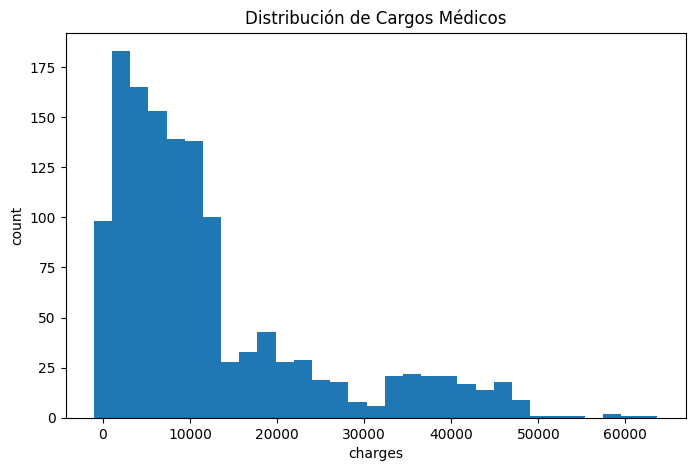

In [56]:
# Pasar el dataframe a Spark
spark_df = df.to_spark()

# Calcular min y max de 'charges'
from pyspark.sql.functions import max,min,floor

row = spark_df.agg(
  max('charges').alias('max_charges'),
  min('charges').alias('min_charges')
).collect()[0]

max_charges = row['max_charges']
min_charges = row['min_charges']

# Calcular el rango de valores 'charges'
rango = max_charges - min_charges

# Definir intervalo del bin (intervalos histograma, recomendable de 10-30)
bin_width = round(rango/30)

# Crear la columna de bins
df_bins = spark_df.withColumn(
  'bin',
  floor(spark_df['charges']/bin_width)
)

# Agrupar y contar cuantas observaxciones hay por intervalo
hist_df = df_bins.groupBy('bin').count().orderBy('bin')

# Agragar columnas para mejor visualización del gráfico. Valores del eje x
hist_df = hist_df.withColumn(
  'bin_start',
  hist_df['bin']*bin_width # Para el eje x, saber el valor inicial de cada bin, ex: (bin 0) 0*2088 = 0, (bin 1) 1*2088= 2088
)

hist_df = hist_df.withColumn(
  'bin_end',
  hist_df['bin']*bin_width+bin_width # Para el eje x, saber el valor final de cada bin, ex: (bin 0) 0*2088+2088 = 2088, (bin 1) 1*2088+2088= 4176
)

# Convertir a pandas
hist_pd = hist_df.toPandas()

# Crear el gráfico
plt.figure(figsize=(8,5))
plt.bar(hist_pd['bin_start'], hist_pd['count'], width=bin_width)

plt.xlabel('charges')
plt.ylabel('count')
plt.title('Distribución de Cargos Médicos')

plt.show()

In [57]:
print(bin_width)

2088


El histograma muesta que la distribución de la variable `charges` está sesgada a la derecha, lo que indica que la mayoría de los asegurados presenta costes médicos relativamente bajos, mientras que existe una cola de valores más elevados correspondientes a casos con gastos médicos significativamente superiores. En estos tipo de distribuciones la media suele ser mayor que la mediana debido a la presencia de valores altos. Además, se observa algunos cercanos a los 60.000 que pueden considerarse outliers, aunque en este contexto son habituales en datos de costes médicos y no necesariamente representan errores.

**Índice de masa corportal (bmi)**

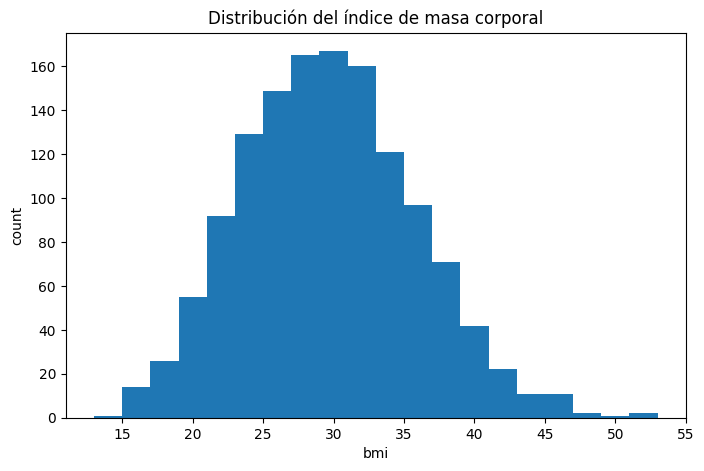

In [58]:
# Cálculos y agregaciones con Spark
row = spark_df.agg(
    max(spark_df['bmi']).alias('max_bmi'),
    min(spark_df['bmi']).alias('min_bmi')
).collect()[0]
max_bmi = row['max_bmi']
min_bmi = row['min_bmi']
rango = max_bmi - min_bmi

bin_width = round(rango/20)
df_bins = spark_df.withColumn(
    'bin',
    floor(spark_df['bmi']/bin_width)
)
hist_bmi = df_bins.groupBy('bin').count().orderBy('bin')

# Agregar columnas para mejor visualización del gráfico
hist_bmi = hist_bmi.withColumn(
    'bin_start',
    hist_bmi['bin']*bin_width
)
hist_bmi = hist_bmi.withColumn(
    'bin_end',
    hist_bmi['bin']*bin_width+bin_width
)

# Pasar a Pandas
hist_bmi_pd = hist_bmi.toPandas()

# Crear el gráfico
plt.figure(figsize=(8,5))
plt.bar(hist_bmi_pd['bin_start'], hist_bmi_pd['count'], width=bin_width)

plt.xlabel('bmi')
plt.ylabel('count')
plt.title('Distribución del índice de masa corporal')

plt.show()

La distribución del índice de la masa corporal (`bmi`) presenta una forma cercana a una distribución normal, aunque ligeramente sesgada a la derecha, con un pico alrededor de 30. Esto indica que la mayor parte de los asegurados presenta valores de BMI próximos a esté rango, esto sugiere que una parte importante de los asegurados podría situarse en rangos de sobrepeso.

Se observa una ligera cola hacia valores más elevados, con algunos registros superiores a 50 que podrían considerarse outliers. No obstante, en este tipo de datasets relacionados con salud es posible encontrar valores altos de BMI asociados a casos de obesidad.

**Edades (`age`):**

Como `age` es una variable discreta y presenta un rango de valores enteros, es interesante visualizar su distribución mediante un gráfico de barras que mueste el número de asegurados por cada edad.

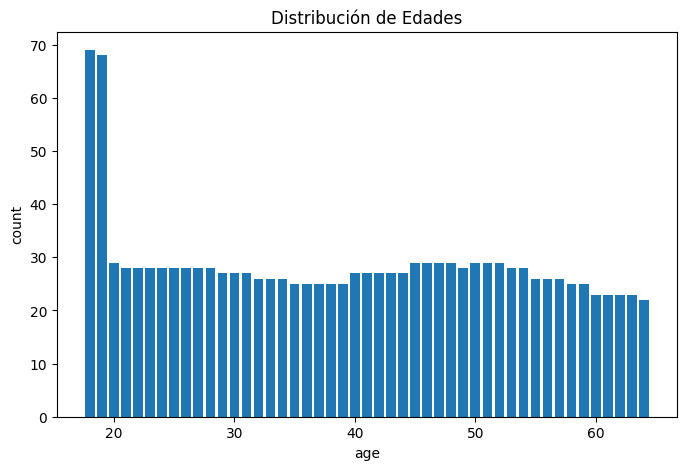

In [59]:
# Agrupar por edades y contar
hist_age = spark_df.groupBy('age').count().orderBy('age')

# Convertir a pandas
hist_age_pd = hist_age.toPandas()

# Crear el gráfico
plt.figure(figsize=(8,5))
plt.bar(hist_age_pd['age'], hist_age_pd['count'])

plt.xlabel('age')
plt.ylabel('count')
plt.title('Distribución de Edades')

plt.show()

La gráfica muestra una distribución relativamente uniforme en la mayoría de las edades de los aseguradoes. No obstante, se observa un pico notable en las edades más jovenes, entre 18 y 19 años, donde el número de asegurados es significativamente mayor que en las otras edades.

**Hijos o dependientes (`children`):**


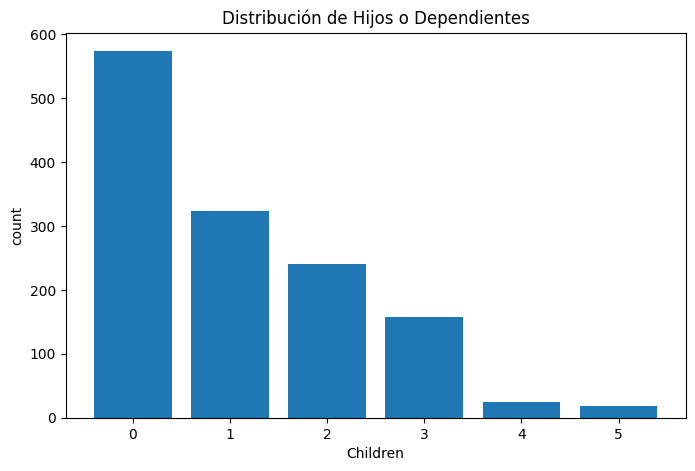

In [60]:
# Agrupar por hijos/dependientes y contar:
hist_children = spark_df.groupBy('children').count().orderBy('children')

# Pasarlo a Pandas
hist_children_pd = hist_children.toPandas()

# Hacer el gráfico
plt.figure(figsize=(8,5))
plt.bar(hist_children_pd['children'], hist_children_pd['count'])

plt.xlabel('Children')
plt.ylabel('count')
plt.title('Distribución de Hijos o Dependientes')

plt.show()

Se observa una clara predominancia de asegurados que no tienen dependientes a su cargo. A medida que aumenta el número de hijos o dependientes, el número de asegurados disminuye progresivamente. Los casos con cuatro y cinco dependientes son muy poco frecuentes dentro del dataset.

#### Distribución de variables categorica
En este apartado se analiza la distribución de las variables categoricas del dataset (`region`, `sex` y `smoker`) mediante gráficas de barras, con el objetivo de observar la frequencia de cada categoría, posibles desequilibrios en la distribución y la proporción de cada grupo dentro del conjunto de datos.


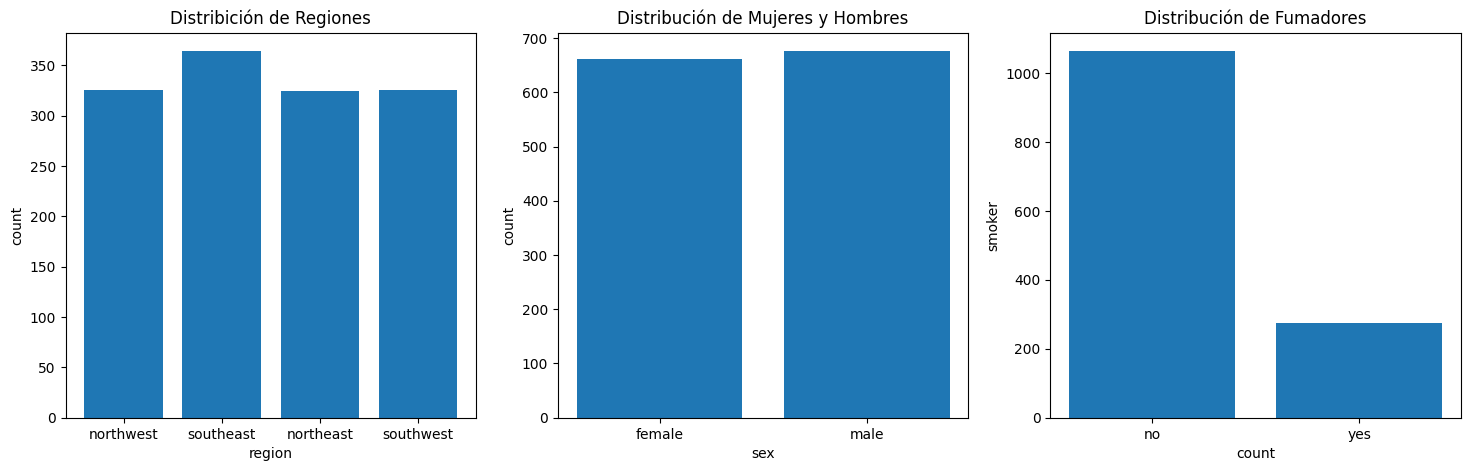

In [61]:
# Agrupar por región y contar
bar_region = spark_df.groupBy('region').count()
bar_region_pd = bar_region.toPandas()

# Agrupar por sexo y contar
bar_sex = spark_df.groupBy('sex').count()
bar_sex_pd = bar_sex.toPandas()

# Agrupar por fumadores y contar
bar_smoker = spark_df.groupBy('smoker').count()
bar_smoker_pd = bar_smoker.toPandas()

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(bar_region_pd['region'], bar_region_pd['count'])
axes[0].set_xlabel('region')
axes[0].set_ylabel('count')
axes[0].set_title('Distribición de Regiones')

axes[1].bar(bar_sex_pd['sex'], bar_sex_pd['count'])
axes[1].set_xlabel('sex')
axes[1].set_ylabel('count')
axes[1].set_title('Distribución de Mujeres y Hombres')

axes[2].bar(bar_smoker_pd['smoker'], bar_smoker_pd['count'])
axes[2].set_xlabel('count')
axes[2].set_ylabel('smoker')
axes[2].set_title('Distribución de Fumadores')

plt.show()


La gráfica de región (`region`) presenta una distribción bastante equilibrada entre todas las regiones del dataset, aunque se observa un ligero predominio de asegurados en la región `southeast`.

La distribución entre mujeres y hombres és bastante equilibrada, con una ligera predominancia de asegurados masculinos.

Se observa una clara diferencia entre fumadores y no fumadores, predominando notablemente los asegurados no fumadores dentro del dataset. Esta variable será especialmente relevante en el análisis bivariante, ya que el hábito de fumar podría estar relacionado con mayores costes médicos.

### Análisis bivariante y multivariante de las variables

Esta etapa permite identificar posibles relaciones entre las varaibles del dataset, descubrir patrones en los datos y obtener indicios sobre los factores que podrían influir en los costes médicos.

**Relación costos médicos con fumadores (`charges - smoker`)**

Se calcula la media y mediana de los costes médicos para fumadores y no fumadores con el objetivo de comprobar si existen outliers que puedan distorsionar la media.

In [62]:
# Crear los datasets con spark
from pyspark.sql import functions as F

# Agrupar y calcular media y mediana de cargos medicos por fumadores y no fumadores
charges_smoker = spark_df.groupBy('smoker').agg(
  F.avg('charges').alias('media_charges'),
  F.percentile_approx('charges', 0.5).alias('mediana_charges')
)

charges_smoker.show()

+------+------------------+---------------+
|smoker|     media_charges|mediana_charges|
+------+------------------+---------------+
|    no|   8434.2682978562|       7345.084|
|   yes|32050.231831532834|     34439.8559|
+------+------------------+---------------+



La diferencia entre media y mediana es pequeña en ambos grupos, lo que indica que los outliers no afectan significativamente al promedio. Sin embargo, los fumadores presentan costes médicos significativamente superiores, unas 3 veces más.

Entendiendo que estamos trabajando en grandes volumenes de datos, para ver la distribución de los cargos médicos en función de si los asegurados son o no fumadores, se realiza un sampling (muestra) de los datos para poder visualizar un boxplot. En este caso se utiliza un muestreo del 99% para mantener prácticamente toda la información del conjunto de datos, pero en Big Data se suele utilizar el 1-5% dependiendo del volumen de datos.

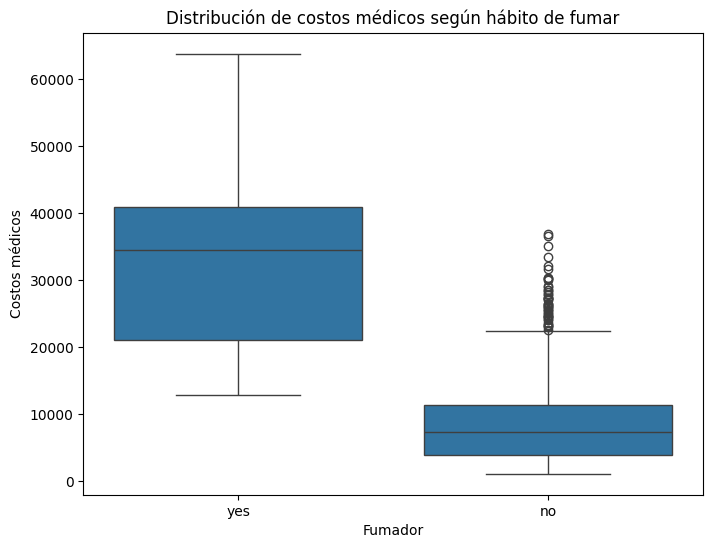

In [63]:
# Se utiliza un sample para simular un escenario de Big Data
sample_df = spark_df.sample(fraction=0.99, seed=42)
box_df = sample_df.select("smoker", "charges").toPandas()

# Graficar
plt.figure(figsize=(8,6))

sns.boxplot(data=box_df, x="smoker", y="charges")

plt.title("Distribución de costos médicos según hábito de fumar")
plt.xlabel("Fumador")
plt.ylabel("Costos médicos")

plt.show()


Los boxplots muestran que los fumadores presentan costos médicos significativamente más altos que los no fumadores. La mediana del grupo de fumadores es considerablemente mayor, lo que indica que la diferencia no se debe únicamente a valores extremos (outliers), sino a un incremento generalizado de los costos en este grupo. Además, existe una mayor dispersión en el grupo de fumadores, lo que sugiere que los costos médicos pueden variar más entre los fumadores que entre los no fumadores. Aunque existen no fumadores con costes médicos altos, no son tan extremos como los de los fumadores.

En conjunto, la variable `smoker` muestra una clara separación en los costos médicos. Los fumadores presentan valores significativamente más altos (con costes medios aproximadamente tres o cuatro veces superiores) y con muy poco solapamiento respecto a los no fumadores, lo que sugiere que el hábito de fumar es uno de los factores más influyentes en la explicación de los costos médicos.

**Relación costos médicos con índice de masa corporal (`charges - bmi`)**


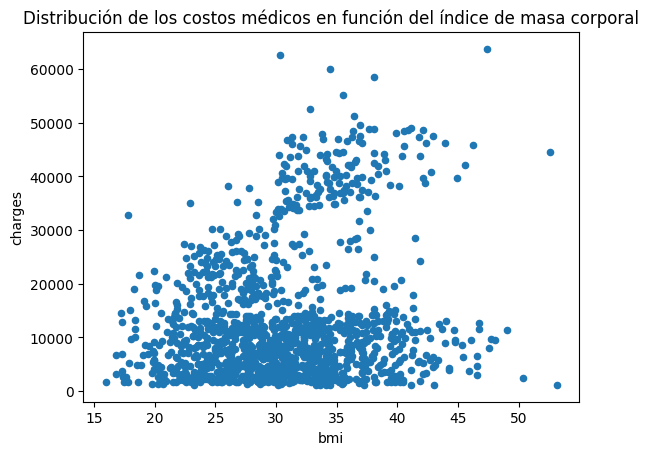

In [64]:
# Pasar el dataframe sample a Pandas
charges_bmi_pd = sample_df.select('charges','bmi').toPandas()

# Graficar
charges_bmi_pd.plot.scatter(
  x='bmi',
  y='charges',
  title='Distribución de los costos médicos en función del índice de masa corporal'
)

plt.show()

El gráfico de dispersión entre el índice de masa corporal (BMI) y los costos médicos muestra una relación débil. Aunque algunos valores de BMI más altos aparecen con costos médicos elevados, la mayoría de los puntos presentan una gran dispersión. Esto sugiere que el BMI por sí solo no explica completamente los costos médicos.

Para un mejor analisis se añade la variable `smoker` para ver como esta afecta a la distribución de costos médicos en función de la masa corporal.

<Axes: xlabel='bmi', ylabel='charges'>

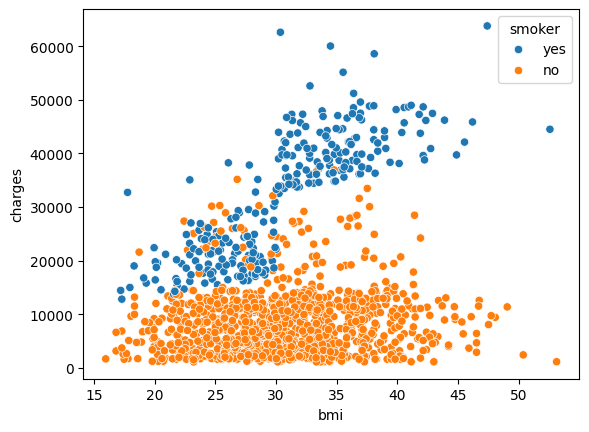

In [65]:
# Pasar el dataframe sample a Pandas
charges_bmi_pd = sample_df.select('charges','bmi','smoker').toPandas()

# Graficar la relación costos médicos - bmi añadiendo fumadores y no fumadores
sns.scatterplot(
    data=charges_bmi_pd,
    x="bmi",
    y="charges",
    hue="smoker"
)

Al introducir la variable `smoker` en el gráfico, se observa un patrón más claro. Los asegurados no fumadores presentan un rango relativamente uniforme de costos médicos, donde el índice de masa corporal no parece influir significativamente. En cambio, en el grupo de fumadores se aprecia una tendencía más clara, donde a medida que aumenta el BMI, también tienden a aumentar los costos médicos. Además, los valores mínimos de costos en fumadores se sitúan por encima de gran parte de los costos observados en los no fumadores.

**Relación costos médicos con hijos o personas dependiente (`charges - children`)**

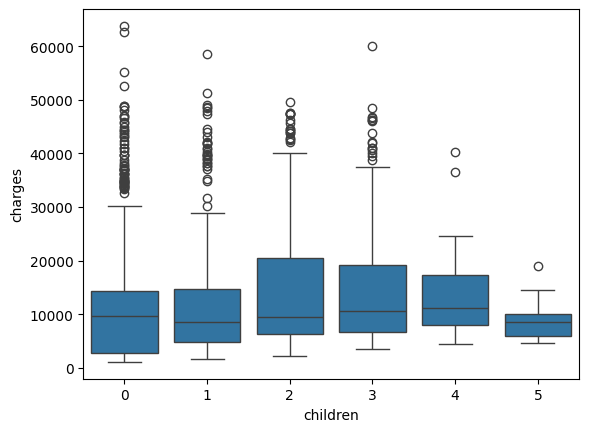

In [66]:
# Pasar el sample a Pandas
charges_children_pd = sample_df.select('charges','children').toPandas()

# Graficar
sns.boxplot(
    data = charges_children_pd,
    x='children',
    y='charges'
)

plt.show()

En la gráfica se observa una gran cantidad de valores atípicos en el grupo de asegurados sin hijos. Aunque la mediana de los costes médicos se mantiene relativamente similar entre los distintos grupos, algunos presentan mayor  dispersió que otros. A primer vista puede sugerirse que los asegurados con dos o tres dependientes tienen más costes médicos, sin embergo, no se puede establecer una relación clara entre el número de hijos y los costes médicos únicamente a partir de este gráfico. Para comprender mejor la posible relación, se analiza a continuación el número de observaciones en cada grupo.

In [67]:
spark_df.groupBy('children').count().orderBy('children').show()

+--------+-----+
|children|count|
+--------+-----+
|       0|  574|
|       1|  324|
|       2|  240|
|       3|  157|
|       4|   25|
|       5|   18|
+--------+-----+



El conteo de observaciones por grupo muestra que la variable `children` presenta una distribución desbalanceada, concentrándose la mayoría de los registros en los grupos con 0, 1 y 2 hijos. En contraste, los grupos con 4 y 5 hijos contienen muy pocas observaciones, por lo que las conclusiones para esos grupos deben interpretarse con cautela.

Por tanto, no se observa una relación clara entre el número de hijos y los costos médicos de forma directa. Esto sugiere que otras variables podrían estar influyendo de forma más significativa en los costes médicos.

**Relación costos médicos con la región (`charges - region`)**

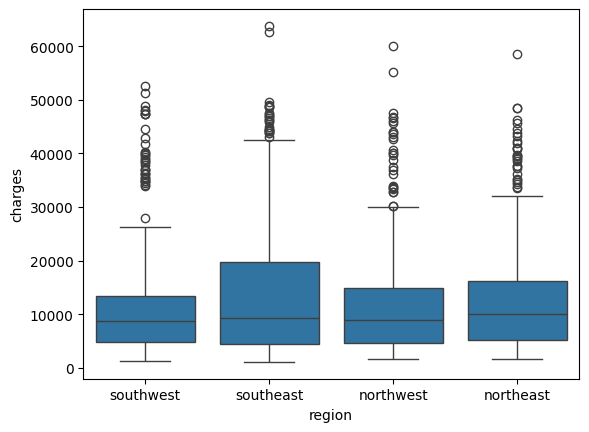

In [68]:
# Pasar a Pandas
charges_region_pd = sample_df.select('charges','region').toPandas()

# Graficar
sns.boxplot(
    data=charges_region_pd,
    x='region',
    y='charges'
)
plt.show()

Se observa que la mediana de costes médicos se mantiene relativamente constante en todas las regiones. Existen valores atípicos en todas ellas, sin embargo, en la región `southeast` el IQR es más alto que los demás. Esta difrencia pordía indicar la presencia de otros factores que estén influyendo en los costes médicos, por lo que se realizará una exploración adicional de varuables por región.

In [69]:
# Conteo de fumadores y no fumadores por región
spark_df.crosstab("region", "smoker").show()

+-------------+---+---+
|region_smoker| no|yes|
+-------------+---+---+
|    northwest|267| 58|
|    southeast|273| 91|
|    northeast|257| 67|
|    southwest|267| 58|
+-------------+---+---+



In [70]:
# Conteo de casos de obesidad por región (bmi>40)
spark_df.filter(spark_df['bmi'] > 40).groupBy('region').count().show()

+---------+-----+
|   region|count|
+---------+-----+
|northwest|    8|
|southeast|   55|
|northeast|   15|
|southwest|   13|
+---------+-----+



El análisis adicional muestra que la región `southeast` presenta un mayor número de asegurados fumadores y también una mayor concentración de valores altos de BMI. Dado que ambas variables se han identificado previamente como factores asociados a mayores costes médicos, esto podría ayudar a explicar por qué en esta región aparecen más valores elevados de charges.

**Relación costos médicos con hombres y mujeres (`charges - sex`)**

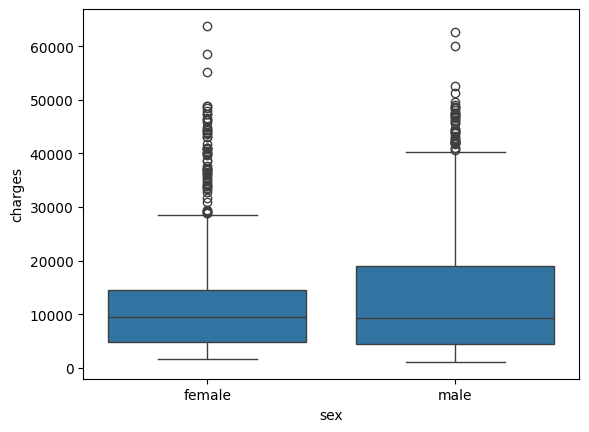

In [71]:
# Pasar a Pandas
charges_sex_pd = sample_df.select('charges', 'sex').toPandas()

# Graficar
sns.boxplot(
    data = charges_sex_pd,
    x='sex',
    y='charges'
)
plt.show()

In [72]:
# Comprobar fumadores por sexo
smokers_sex=spark_df.crosstab("sex", "smoker")

# Añadir una columna de porcentaje de fumadores
smokers_sex.withColumn(
    '% fumadores',
    (smokers_sex['yes']/smokers_sex['no']) * 100
).show()

+----------+---+---+------------------+
|sex_smoker| no|yes|       % fumadores|
+----------+---+---+------------------+
|    female|547|115|21.023765996343695|
|      male|517|159|30.754352030947775|
+----------+---+---+------------------+



El análisis de los costes médicos según el sexo muestra una distribución relativamente similares entre hombres y mujeres, aunque la dispersión y algunos valores elevados parecen ligeramente mayores en el grupo masculino.

Una exploración adicional mediante una table cruzada muestra que la proporción de fumadores es mayor en los hombres (aproximadamente un 30%) que entre las mujeres (alrededor de un 21%). Dado que el hábito de fumar se ha identificado previamente como uno de los factores más influyentes en los costes médicos, esta diferencia podría explicar la ligera variación observada entre ambos grupos.

**Relación costos médicos con la edad (`charges - age`)**

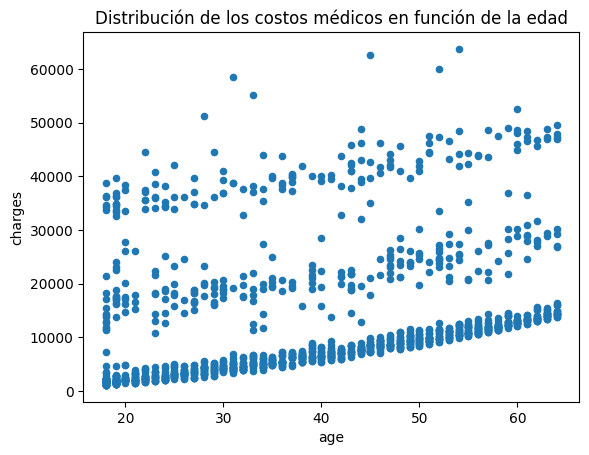

In [73]:
 # Pasarlo a Pandas
charges_age_df = sample_df.select('age', 'charges').toPandas()

# Graficar
charges_age_df.plot.scatter(x='age', y='charges', title='Distribución de los costos médicos en función de la edad')
plt.show()

El gráfico muestra una tendencia positiva moderada entre la edad y los costos médicos, ya que a medida que aumenta la edad tienden a incrementarse los cárgos médicos. Sin embargo, se observa una alta dispersión de los puntos, lo que indica que la edad por sí sola no explica completamente los casos médicos. Además, se distinguesn aproximadamente tres franjas de puntos, lo que sugiere que existen otras variables que también influyen en el aumento de los costos médicos.

**Relación entre edad, BMI y costes médicos según hábito de fumar**

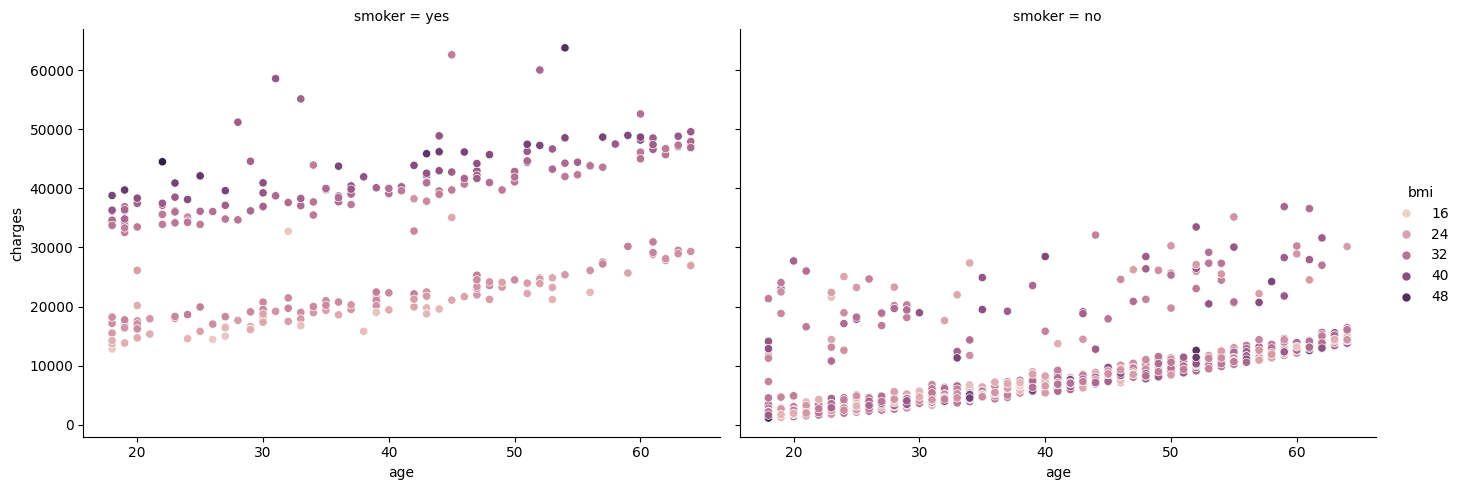

In [74]:
# Pasar el dataframe sample a Pandas
df = sample_df.select('age','charges','bmi','smoker').toPandas()

# Hacer el gráfico
sns.relplot(
    data=df,
    x="age",
    y="charges",
    hue="bmi",
    col="smoker",
    height=5,
    aspect=1.4
)


En el grupo de fumadores se observa que los costes médicos tienden a aumentar con valores más altos de BMI. En cambio, entre los no fumadores esta relación es menos clara y los costes médicos se mantienen en rangos significativamente más bajos. Además, en el grupo de no fumadores se aprecia una relación más regular entre la edad y los costes médicos, mientras que en el grupo de fumadores existe una mayor dispersión y aparecen valores significativamente más altos, lo que sugiere que el hábito de fumar introduce una mayor variabilidad en los costes médicos.

La separación clara entre fumadores y no fumadores sugiere que el hábito de fumar es una de las variables más influyentes en los costes médicos del dataset.

### Conclusión del análisis exploratorio
Tras el análisis exploratorio de los datos, se observa que existe una fuerte relación entre la variable `smoker` y los costes médicos. Los asegurados fumadores presentan costes significativamente más elevados que los no fumadores, lo que sugiere que el hábito de fumar es uno de los factoes más influyente en el incremento de `charges`.

Asimismo, se observa que una parte relevante de los asegurados presenta valores elevados de BMI, con muchos casos por encima de 30, lo que indica la presencia de obesidad en una proporción importante de la muestra.

También se identifica una relación positiva entre la edad y los costes médicos, a medida que aumenta la edad, los costes tienden a incrementar. No obstante, esta relación presenta diferentes franjas, lo que sugiere que otras variables del dataset también influyen en el comportamiento de `charges`.

Finalmente, el análisis multivariante muestra que los costes médicos son especialmente elevados en asegurados fumadores con valores altos de BMI, lo que indica que la combinación de estos factores puede contribuir a un mayor incremento de los gastos médicos.

**Key Insights:**

1. El hábito de fumar es el factor más influyente en los costes médicos.
2. Existe una relación positiva entre la edad y los costes médicos.
3. El BMI muestra un mayor impacto en fumadores.
4. Variables como sexo, región o número de hijos no muestran una relación clara con los costes médicos.



## Modelo de Regresión Lineal

En este caso, la variable objetivo del modelo es `charges`, que representa los costes médicos individuales facturados por el seguro de salud. El objetivo del modelo es predecir estos costes en función de las características del asegurado.

Las variables predictoras son: `age`, `sex`, `bmi`, `children`, `smoker` y `region`.



In [75]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

### Transformación de variables
Para preparar los datos para el modelo de regresión lineal, es necesario transformar las variables categóricas y numéricas del dataset a un formato adecuado para los algorirmos de machine learning en Spark.

Las variables categóricas `sex`, `smoker` y `region` se transforman mediante `StringIndexer`, lo que permite convertir los valores categóricos en índices numéricos. Este proceso es necesario ya que los modelos de machine learning no pueden trabajar directamente con variables de tipo string. Seguido de `StringIndexer` se aplica `OneHotEncoder`, con el objetivo de evitar un orden artificial entre categorías.

En cuanto a las variables numéricas `age`, `bmi` y `children` se agrupan mediante `VectorAssembler` para crear un vector de características numéricas y posteriormente, se aplica `StandardScaler` con el objetivo de escalar y homogeneizar sus magnitudes.

Finalmente, todas las variables transformadas se combinan mediante un `VectorAssembler` final para crear la columna `features`, que utilizará por el modelo de regresión lineal.

Todos las transformacione se realizaran a partir de un Pipeline, lo que permite estructurar y automatizar el proceso de preparación de los datos.

In [91]:
# Transformación de variables categóricas
smoker_indexer = StringIndexer(inputCol='smoker', outputCol='smoker_index')
sex_indexer = StringIndexer(inputCol='sex', outputCol='sex_index')
region_indexer = StringIndexer(inputCol='region', outputCol='region_index')
encoder = OneHotEncoder(
    inputCols=["smoker_index", "sex_index", "region_index"],
    outputCols=["smoker_ohe", "sex_ohe", "region_ohe"]
)

# Transformación de variables numéricas
assembler = VectorAssembler(inputCols=['age', 'children','bmi'], outputCol='num_features')
scaler_num_features = StandardScaler(inputCol='num_features', outputCol='scaled_num_features')

# Unir todas en un solo vector 'features'
vec_assembler = VectorAssembler(inputCols=['smoker_ohe','sex_ohe','region_ohe','scaled_num_features'], outputCol='features')


### División del conjunto de datos
El dataset se divide en un 80% para entrenamiento y un 20% para prueba, con el objetivo de entrenar el modelo y evaluar su capacidad de generalización sobre datos no vistos.

In [92]:
# Split Dataset
trainingData, testData = spark_df.randomSplit([0.8, 0.2], seed=42)

print("Training Dataset Count: " + str(trainingData.count()))
print("Test Dataset Count: " + str(testData.count()))

Training Dataset Count: 1089
Test Dataset Count: 249


### Entrenamiento del modelo de regresión lineal
El modelo se entrena mediante un Pipeline, donde el orden de los `stages` es importante, ya que determina cómo se aplican las transformaciones hasta la construcción final de la columna `features`, que será utilizada como entrada del modelo.

In [94]:
lr = LinearRegression(featuresCol='features', labelCol='charges')

# Definir el pipelione
stages = [
    smoker_indexer,
    sex_indexer,
    region_indexer,
    encoder,
    assembler,
    scaler_num_features,
    vec_assembler,
    lr]
pipeline = Pipeline(stages=stages)

# Entrenar el modelo
model = pipeline.fit(trainingData)

### Generación de predicciones
Una vez entrenado el modelo, se aplican las transformaciones del pipeline sobre el conjunto de datos de prueba (`testData`) mediante el método `transform`. Este proceso permite generar predicciones a partir de las características de los asegurados.

El resultado es un nuevo DataFrame que incluye la columna `prediction`, que representa el valor estimado de los costes médicos (`charges`) para cada observación.

In [95]:
predictions = model.transform(testData)


### Evaluación del modelo
**Métricas de evaluación**:

Para evaluar el rendimiento del modelo se utilizan métricas de regresión como RMSE, MAE y R², que permiten medir el error de predicción y la capacidad del modelo para explicar la variabilidad de los costes médicos.

In [96]:
evaluator = RegressionEvaluator(labelCol='charges', predictionCol='prediction')

rmse = evaluator.evaluate(predictions, {evaluator.metricName: "rmse"})
r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})
mae = evaluator.evaluate(predictions, {evaluator.metricName: "mae"})

print("RMSE:", rmse)
print("R2:", r2)
print("MAE:", mae)

RMSE: 5972.991279712986
R2: 0.7734481084487491
MAE: 4169.426353976578


El modelo presenta un coeficiente de determinación R2 de aproximadamente 0.773, lo que indica que es capaz de explicar alrededor del 77.3% de la variabilidad de los costes médicos (`charges`). Esto sugiere que el modelo tiene una buena capacidad explicativa.

En cuanto al error de predicción, el error absoluto medio (MAE) es de aproximadamente 4169 dólares, lo que significa que, en promedio, las predicciones del modelo se desvían en unos 4000 dólares respecto al valor real.

Por su parte, el RMSE es de aproximadamente 5973 dólares, lo que indica que existen algunas predicciones con errores más elevados, ya que esta métrica penaliza en mayor medida los errores grandes.

En conjunto, estas métricas indican que el modelo captura adecuadamente la tendencia general de los datos, aunque las predicciones individuales presentan cierto nivel de error.

**Interpretación de los coeficientes del modelo**:

Los coeficientes del modelo permiten analizar la influencia de cada variable predictora sobre el coste médico estimado.

In [97]:
lr_model = model.stages[-1]

print("Coeficientes:", lr_model.coefficients)
print("Intercept:", lr_model.intercept)

Coeficientes: [-23749.71175887154,-286.17042669684935,-1060.5426529970396,-1110.5942844951799,-95.48157836506816,3588.9306502968166,567.883384153651,2035.1591732720706]
Intercept: 11965.835635480702


El modelo de regresión lineal genera un conjunto de coeficientes asociados a cada variable predictora, así como un intercepto.

El `intercept` representa el valor base estimado de los costes médicos cuando todas las variables toman valor cero. Dado que este escenario no tiene una interpretación real en el contexto del dataset, este no se analiza en detalle.

Los `coeficientes` permiten analizar la influencia de cada variable sobre el valor predicho de `charges`. Los coeficientes positivos indican que un aumento en la variable incrementa el coste estimado, mientras que los coeficientes negativos indican una relación inversa.

Es importante tener en cuenta que, debido al uso de variables categóricas codificadas mediante `OneHotEncoder`, la interpretación del signo de los coeficientes se realiza en relación con una categoría de referencia.

Para facilitar su interpretación, se asocian los coeficientes con sus variables correspondientes.

In [102]:
# Obtener los metadatos reales de la columna features
features_metadata = model.transform(testData).schema["features"].metadata   # Ejecuta el pipeline sobre el testData, crea la columna 'features', accede a su metadata interna

# Extraer nombres de variables del vector de features
feature_names = []
for attr_type in ["binary", "numeric"]:   # Spark guarda los tipos de variables serpados en 'binary' y 'numeric'
    if attr_type in features_metadata["ml_attr"]["attrs"]:  # Comprobar si existen (no siempre hay de ambos tipos)
        # Añadirlos a la lista
        feature_names.extend(
            [attr["name"] for attr in features_metadata["ml_attr"]["attrs"][attr_type]]  # Extraer nombres reales, entra en el metadata, recorre cada variable, saca el nombre
        )

# Obtener coeficientes
coefficients = lr_model.coefficients.toArray()

# Mostrar nombre + coeficiente
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef}")


smoker_ohe_no: -23749.71175887154
sex_ohe_male: -286.17042669684935
region_ohe_southeast: -1060.5426529970396
region_ohe_southwest: -1110.5942844951799
region_ohe_northwest: -95.48157836506816
scaled_num_features_0: 3588.9306502968166
scaled_num_features_1: 567.883384153651
scaled_num_features_2: 2035.1591732720706


Para garantizar una interpretación correcta de los coeficientes del modelo, los nombres de las variables se extraen automáticamente a partir de los metadatos de la columna `features`. De este modo, se asegura que la correspondencia entre cada coeficiente y su variable asociada respete el orden exacto generado por el `VectorAssembler` y las transformaciones previas del pipeline.

Esto es especialmente relevante en presencia de variables categóricas codificadas mediante `OneHotEncoder`, ya que estas generan múltiples componentes dentro del vector de características.

En el caso de las variables numéricas, estas han sido transformadas mediante `StandardScaler`, por lo que aparecen como componentes del vector `scaled_num_features`. En este caso, los coeficientes `scaled_num_features_0`, `scaled_num_features_1` y `scaled_num_features_2` corresponden, respectivamente, a las variables `age`, `children` y `bmi`, siguiendo el orden definido en el `VectorAssembler`.

A partir de esta correspondencia, se observa que las variables asociadas al hábito de fumar presentan la mayor magnitud en los coeficientes, lo que indica que son las más influyentes en la predicción de los costes médicos. Asimismo, las variables numéricas relacionadas con la edad y la condición física del asegurado también muestran una influencia relevante, mientras que variables como el sexo (`sex`) o la región (`region`) tienen un impacto menor.

El análisis de los coeficientes confirma los patrones observados previamente en el análisis exploratorio de datos.

**Ejemplos de predicción**

Para ilustrar el comportamiento del modelo, se muestran algunos ejemplos de valores reales (`charges`) junto con sus correspondientes predicciones (`prediction`) generadas sobre el conjunto de datos de prueba.


In [103]:
predictions.select("charges", "prediction").show(10)

+----------+------------------+
|   charges|        prediction|
+----------+------------------+
| 2196.4732|1332.9240547217123|
|2203.47185| 3047.183864438357|
| 1622.1885|  2407.12003269257|
|36149.4835|28029.409538027176|
| 1633.0444| 5066.180432670122|
| 1705.6245|  593.930282061976|
|34303.1672|26928.993365452454|
| 1149.3959| 6090.814428497422|
|  1743.214|1777.2448908843708|
|  1744.465|2083.6667039419626|
+----------+------------------+
only showing top 10 rows


A partir de esta comparación, se observa que el modelo es capaz de aproximar razonablemente los costes médicos reales, aunque existen diferencias en algunos casos, lo que refleja el error inherente del modelo.

En general, el modelo de regresión lineal proporciona una estimación adecuada de los costes médicos a partir de las características del asegurado, capturando la tendencia general de los datos.